In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import joblib

# 1. Data load karo
df = pd.read_csv('../data/telco_churn.csv')

# 2. Cleaning - 'TotalCharges' ko number banao, spaces hatao
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

# 3. Target column ko 0/1 mein convert karo
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 4. Categorical columns ko number mein badlo
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols.remove('customerID') # ID hata do
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# 5. Model train karo
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. Model save karo
joblib.dump(model, 'churn_model.pkl')
print("Model trained. Accuracy:", model.score(X_test, y_test))

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20996\3637738669.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


Model trained. Accuracy: 0.7924662402274343


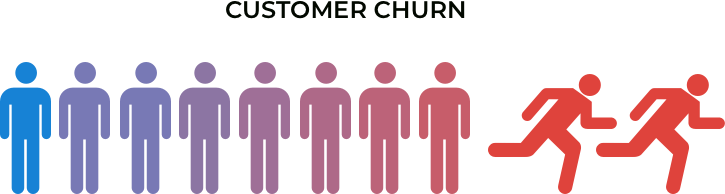

Customer churn is a fundamental problem for the telecommunication (Telco) industry. It is defined as the loss of customers moved from one Telco operator to another. If customer churn can be predicted in advance, such as “is this customer going to leave us within the next X months?”, Telco operators can apply business marketing policies to such churn customers to retain and increase the customer base. In particular, given millions of Telco customers, even reducing the 1% churn rate will lead to a significant profit increase.

We can roughly define the **Churn** analysis as the whole of analytical studies on “a customer”, “a product or service”, and “the probability of abandonment”. We aim to be aware of this situation (even the customer himself may not be aware of this situation) before the customer leaves us (approaching to leave) and then to take some preventive actions.

***Telco churn*** data includes information about a fictitious telecom company that provided home phone and Internet services to 7,043 California customers in the third quarter. Which customers have left, stayed, or signed up for their service shows?

**Business Problem**

It is desirable to develop a machine learning model that can predict customers who will leave the company. You are expected to perform the necessary data analysis and feature engineering steps before developing the model.

In this project, the dataset named Telco Customer Churn from Kaggle was used. Each row represents a customer, each column contains the customer's attributes. This dataset contains 21 columns (variables) and 7043 rows (customers) with information such as customerID, gender, Phone Service, and Internet Service. Table 1 shows the data types of the variables with 17 categorical and 4 numerical data.

Analysis of data columns to identify independent and dependent variables:

**X is the independent variables -  the variables we are using to make predictions**

* customerID - unique value identifying customer
* gender - whether the customer is a male or a female
* SeniorCitizen - whether the customer is a senior citizen or not (1, 0)
* Partner - whether the customer has a partner or not (Yes, No)
* Dependents - whether the customer has dependents or not (Yes, No). A dependent is a person who relies on another as a primary source of income,
* tenure - number of months the customer has stayed with the company
* PhoneService - whether the customer has a phone service or not (Yes, No)
* MultipleLines - whether the customer has multiple lines or not (Yes, No, No phone service)
* InternetService - customer’s internet service provider (DSL, Fiber optic, No)
* OnlineSecurity - whether the customer has online security or not (Yes, No, No internet service)
* OnlineBackup - whether the customer has online backup or not (Yes, No, No internet service)
* DeviceProtection - whether the customer has device protection or not (Yes, No, No internet service)
* TechSupport - whether the customer has tech support or not (Yes, No, No internet service)
* StreamingTV - whether the customer has streaming TV or not (Yes, No, No internet service)
* StreamingMovies - whether the customer has streaming movies or not (Yes, No, No internet service)
* Contract - type of contract according to duration (Month-to-month, One year, Two year)
* PaperlessBilling - bills issued in paperless form (Yes, No)
* PaymentMethod - payment method used by customer (Electronic check, Mailed check, Credit card (automatic), Bank transfer (automatic))
* MonthlyCharges - amount of charge for service on monthly bases
* TotalCharges - cumulative charges for service during subscription (tenure) period

**y is dependent variable - variable we are trying to predict or estimate**

* Churn – output value, predict variable

**Import libraries**

First, let's import the necessary Python libraries:

In [2]:
# for data manipulation
import numpy as np
import pandas as pd

# for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# for data splitting, transforming and model training
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Import Warnings
import warnings
warnings.simplefilter(action="ignore")

ModuleNotFoundError: No module named 'catboost'

In [ ]:
# Setting Configurations:

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

**Data Reading**

***Let's import the dataset.***

The first step of the analysis consists of reading and storing the data in a Pandas data frame using the pandas.read_csv function.

In [ ]:
df = pd.read_csv("/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

**Let's look at the first 5 observations of the dataset.**

In [ ]:
df.head()

**After using the head function, we can see that this database has some null values (using the info function we can confirm this), and our target variable is "Churn", we can also see that we have Numerical and Categoricals, here we can see too that we only have few variables.**

In [ ]:
def check_data(dataframe, head=5):

    print(20*"-" + "Information".center(20) + 20*"-")
    print(dataframe.info())
    print(20*"-" + "Data Shape".center(20) + 20*"-")
    print(dataframe.shape)
    print("\n" + 20*"-" + "The First 5 Data".center(20) + 20*"-")
    print(dataframe.head())
    print("\n" + 20 * "-" + "The Last 5 Data".center(20) + 20 * "-")
    print(dataframe.tail())
    print("\n" + 20 * "-" + "Missing Values".center(20) + 20 * "-")
    print(dataframe.isnull().sum())
    print("\n" + 40 * "-" + "Describe the Data".center(40) + 40 * "-")
    print(dataframe.describe([0.01, 0.05, 0.10, 0.50, 0.75, 0.90, 0.95, 0.99]).T)


check_data(df)

**#Column "TotalCharges" is an object, and we have to convert it to a numeric value** 

In [ ]:
pd.to_numeric(df.TotalCharges, errors='coerce').isna()
df.TotalCharges = pd.to_numeric(df.TotalCharges, errors='coerce') # Using errors=coerce. It will replace all non-numeric values with NaN.

**#Let's convert the dependent variable to binary variable.**

First of all, we digitize the target variable, the churn variable, and make it suitable for analysis. Because we will shape all other variables according to their relationship with churn.

In [ ]:
# To find the number of churners and non-churners in the dataset:
df["Churn"].value_counts()

In [ ]:
df["Churn"] = df["Churn"].map({'No': 0, 'Yes': 1})

**To see the histogram chart:**
Histograms are a great way to explore columns with numerical data.

In [ ]:
num_bins = 20
df.hist(bins=num_bins, figsize=(30,20))
plt.savefig("churn_histogram")
plt.show()

In [ ]:
 def grab_col_names(dataframe, cat_th=10, car_th=20):  
    """
    It gives the names of categorical, numerical and categorical but cardinal variables in the data set.
    Note: Categorical variables with numerical appearance are also included in categorical variables.

    Parameters
    ------
            df: Dataframe
                The dataframe from which variable names are to be retrieved
        cat_th: int, optional
                threshold value for numeric but categorical variables
        car_th: int, optinal
                threshold value for categorical but cardinal variables

    Returns
    ------
        cat_cols: list
                Categorical variable list
        num_cols: list
                Numeric variable list
        cat_but_car: list
                Categorical but cardinal variable list

    Examples
    ------
        You just need to call the function and send the dataframe.)
        
        --> grab_col_names(df)

    Notes
    ------
        cat_cols + num_cols + cat_but_car = total number of variables
        num_but_cat is inside cat_cols.
        The sum of the 3 returned lists equals the total number of variables: 
        cat_cols + num_cols + cat_but_car = number of variables

    """

In [ ]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
  
    # cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and dataframe[col].dtypes != "O"]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and dataframe[col].dtypes == "O"]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # num_cols
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')

    return cat_cols, num_cols, cat_but_car


cat_cols, num_cols, cat_but_car = grab_col_names(df)

cat_cols
num_cols


# Analyze the numerical and categorical variables.

In [ ]:
def target_vs_category_visual(dataframe, target, categorical_col):
    plt.figure(figsize=(15, 8))
    sns.histplot(x=target, hue=categorical_col, data=dataframe, element="step", multiple="dodge")
    plt.title("State of Categorical Variables according to Churn ")
    plt.show()


for col in cat_cols:
    target_vs_category_visual(df, "Churn", col)

# Perform target variable analysis. 

**(The mean of the target variable according to the categorical variables, the mean of the numeric variables according to the target variable)**

In [ ]:
def target_summary_with_num(dataframe, target, numerical_col):
    print(dataframe.groupby(target).agg({numerical_col: "mean"}), end="\n\n")

for col in num_cols:
    target_summary_with_num(df, "Churn", col)

We continue the analysis by examining the relationship of the Churn variable with other variables.

In [ ]:
def target_summary_with_cat(dataframe, target, categorical_col):
    print(pd.DataFrame({"CHURN_MEAN": dataframe.groupby(categorical_col)[target].mean()}))


for col in cat_cols:
    target_summary_with_cat(df, "Churn", col)

* There is no significant difference in the number of departures of male and female customers.
* The churn rate of customers paying by electronic check seems high.
* Customers with monthly contracts seem to have a high churn rate.
* It seems that customers using fiber optic internet have a high churn rate.

**Perform outlier observation analysis.**

In [ ]:
def outlier_thresholds(dataframe, col_name, q1=0.05, q3=0.95):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
        return True
    else:
        return False

def grab_outliers(dataframe, col_name, index=False):
    low, up = outlier_thresholds(dataframe, col_name)

    if dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].shape[0] > 10:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].head())
    else:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))])

    if index:
        outlier_index = dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].index
        return outlier_index

for col in num_cols:
    print(col, check_outlier(df, col))

**Perform a missing observation analysis.**

In [ ]:
def missing_values_table(dataframe, na_name=False):
    na_columns = [col for col in dataframe.columns if dataframe[col].isnull().sum() > 0]

    n_miss = dataframe[na_columns].isnull().sum().sort_values(ascending=False)
    ratio = (dataframe[na_columns].isnull().sum() / dataframe.shape[0] * 100).sort_values(ascending=False)
    missing_df = pd.concat([n_miss, np.round(ratio, 2)], axis=1, keys=['n_miss', 'ratio'])
    print(missing_df, end="\n")

    if na_name:
        return na_columns


missing_values_table(df)

**Perform correlation analysis.**

In [ ]:
corr_matrix = df[num_cols].corr()
corr_matrix

In [ ]:
df.corrwith(df["Churn"]).sort_values(ascending=False)

In [ ]:
# Correlation between all variables
plt.figure(5, figsize=(25, 10))
corr = df.apply(lambda x: pd.factorize(x)[0]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
ax = sns.heatmap(corr, mask=mask, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, linewidths=.2, cmap='coolwarm', vmin=-1, vmax=1)

In [ ]:
# Correlation between churn and selected boolean and numeric variables
plt.figure()
ds_corr = df[['SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'PaperlessBilling',
        'MonthlyCharges', 'TotalCharges']]

correlations = ds_corr.corrwith(df.Churn)
correlations = correlations[correlations!=1]
correlations.plot.bar(
        figsize = (20, 10),
        fontsize = 12,
        color = '#9BCD9B',
        rot = 40, grid = True)

plt.title('Correlation with Churn Rate \n', horizontalalignment="center", fontstyle = "normal", fontsize = "20", fontfamily = "charter")

**By looking at the correlation results, we can make the following comments.**

* There is a positive correlation between churn and the age of customers - most senior citizens churn. Maybe there is some campaign by competitors targeting the senior population.
* Logically, longer tenure could also mean more loyalty and less churn risk.
* It is also logical that more monthly charges can result in more churn risk.
* However, it is interesting that total charges show a negative correlation to churn. The explanation can be that total charges also depend on the time the customer has spent with a company (tenure has a negative correlation). Also, it is questionable whether TotalCharges is an adequate variable to understand customer behavior and whether is it tracked by the customer.
* A positive correlation between paperless billing and churn is something that needs extra exploring (not clear what can be divers for that behavior).

**Take necessary actions for missing and contradictory observations.**

In [ ]:
na_cols = missing_values_table(df, True)
df.dropna(inplace=True)

In [ ]:
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)
df.isnull().sum()

**Perform the encoding operations.**

***Label Encode Binary data:*
Independent variables for machine learning algorithms can typically only have numerical values. Label encoding is used for all categorical variables with only two unique values.**

In [ ]:
le = LabelEncoder()

binary_cols = [col for col in df.columns if df[col].dtype not in [int, float]
               and df[col].nunique() == 2]

def label_encoder(dataframe, binary_col):
    labelencoder = LabelEncoder()
    dataframe[binary_col] = labelencoder.fit_transform(dataframe[binary_col])
    return dataframe

for col in binary_cols:
    df = label_encoder(df, col)

def one_hot_encoder(dataframe, categorical_cols, drop_first=True):
    dataframe = pd.get_dummies(dataframe, columns=categorical_cols, drop_first=drop_first)
    return dataframe

ohe_cols = [col for col in df.columns if 30 >= df[col].nunique() > 2]

df = one_hot_encoder(df, ohe_cols)

In [ ]:
df.info()

**Standardize for numeric variables.**

In [ ]:
num_cols = [col for col in num_cols if col not in "customerID"]
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df[num_cols].head()

In [ ]:
df.head()

**Build a model.**

In [ ]:
y = df['Churn']
X = df.drop(["customerID", "Churn"], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=17)

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=46).fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
accuracy_score(y_pred, y_test)

**Conclusion**

Presently telecom market is facing severe competition. Customer churn prediction has become an important issue of customer relationship management to retain valuable customers. Therefore by performing research, key factors of churn to retain customers and their influence on churn will be well understood.

Proper churn management can save a huge amount of money for the company. Thus the economic value of customer retention can be summarized as: 

* satisfied customers can bring new customers 
* long-term customers usually do not get influenced much by competitors 
* long-term customers tend to buy more 
* company can focus on satisfying existing customer’s needs 
* lost customers share negative experiences and thus will have a negative influence on the image of the company

Thus customer retention as a function of i.e. {Price, service quality, customer satisfaction, brand image} could lead to better customer loyalty.

**In future studies**, different methods will be tried to compare different algorithms and their model accuracy.